In [3]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

def results(x,final_wf, energies, analytic_fn = None):

    if analytic_fn is not None:
        yy = analytic_fn(x)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.plot(x, final_wf, label='Numerical', color='blue')
    if analytic_fn is not None:
        ax1.plot(x, yy, label='Analytic', linestyle='dashed', color='orange')
    ax1.set_title('Wavefunction Comparison')
    ax1.set_xlabel('x')
    ax1.set_ylabel(r'$|\psi(x)|^2$')
    ax1.legend()
    ax1.grid()
    ax2.plot(energies, marker='o', linestyle='-', color='green')
    ax2.set_title('Energy Convergence')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Energy')
    
    


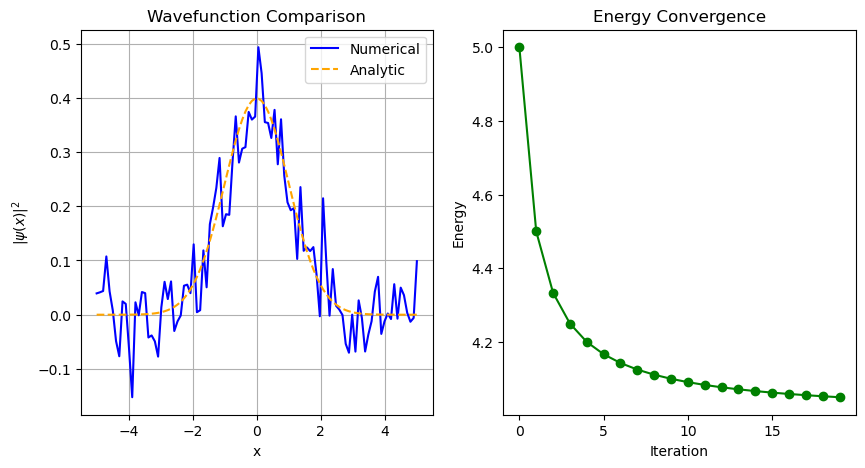

In [4]:
def gaussian(x, mu=0.0, sigma=1.0):
    return (1/(sigma * jnp.sqrt(2 * jnp.pi))) * jnp.exp(-0.5 * ((x - mu) / sigma) ** 2)

x = np.linspace(-5, 5, 100)
noisy_data = gaussian(x, mu=0.0, sigma=1.0) + 0.05 * np.random.normal(size=x.shape)

def energy_convergence(energy):
    return 1/energy + 4

energy_hist = [energy_convergence(i) for i in range(1, 21)]

results(x, noisy_data, energy_hist, analytic_fn=lambda x: gaussian(x, mu=0.0, sigma=1.0))